# Parameter-Free Hierarchical Clustering: K* Means with Automatic Level 2 K Selection

This notebook implements a **fully automatic, parameter-free hierarchical clustering algorithm** for customer segmentation:

**Level 1 (K* Means)**: Automatically determines optimal K using MDL principle → Micro-segments
**Level 2 (Weighted K-Means with Auto K)**: Automatically finds optimal K ensuring business actionability → Macro-segments

## Key Innovation: Zero-Parameter Hierarchical Clustering

**Algorithm Features:**
- **Level 1**: K* Means with MDL-based automatic K selection
- **Level 2**: Automatic K selection with business-driven constraints
  - Start K heuristic: `min(10, max(3, K_Level1 // 10))`
  - Loop from high to low until all clusters meet minimum threshold
  - Absolute floor: K=2 (best-effort even if threshold not met)
  - Configurable minimum threshold: 5-20% (default 10%)
  - Population-weighted clustering for balanced segments

**Business Value:**
- No manual K tuning required
- Ensures all Level 2 segments are actionable (≥10% of population)
- Hierarchical "buckets within buckets" for drill-down analysis
- Marketing teams get both strategic overview (Level 2) and tactical detail (Level 1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus, KMeans
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Instacart User Features Dataset

Load the customer segmentation feature matrix created from the Instacart Market Basket Analysis dataset.

In [3]:
# Load the feature matrix
data_path = r"c:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\8th exploration instacart\instacart_user_features.csv"
df = pd.read_csv(data_path)

print("="*80)
print("INSTACART USER FEATURES DATASET")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Users: {len(df):,}")
print(f"Features: {len(df.columns)-1} (excluding user_id)")
print(f"\nColumns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

INSTACART USER FEATURES DATASET
Shape: (206209, 37)
Users: 206,209
Features: 36 (excluding user_id)

Columns: ['user_id', 'total_orders', 'avg_days_between_orders', 'avg_basket_size', 'reorder_rate', 'total_products_purchased', 'unique_products', 'preferred_day_of_week', 'preferred_hour_of_day', 'day_consistency', 'hour_consistency', 'frequency_consistency', 'unique_aisles', 'unique_departments', 'product_exploration_rate', 'avg_products_per_aisle', 'dept_pct_alcohol', 'dept_pct_babies', 'dept_pct_bakery', 'dept_pct_beverages', 'dept_pct_breakfast', 'dept_pct_bulk', 'dept_pct_canned_goods', 'dept_pct_dairy_eggs', 'dept_pct_deli', 'dept_pct_dry_goods_pasta', 'dept_pct_frozen', 'dept_pct_household', 'dept_pct_international', 'dept_pct_meat_seafood', 'dept_pct_missing', 'dept_pct_other', 'dept_pct_pantry', 'dept_pct_personal_care', 'dept_pct_pets', 'dept_pct_produce', 'dept_pct_snacks']

First few rows:


,user_id,total_orders,avg_days_between_orders,avg_basket_size,reorder_rate,total_products_purchased,unique_products,preferred_day_of_week,preferred_hour_of_day,day_consistency,...,dept_pct_household,dept_pct_international,dept_pct_meat_seafood,dept_pct_missing,dept_pct_other,dept_pct_pantry,dept_pct_personal_care,dept_pct_pets,dept_pct_produce,dept_pct_snacks
0,1,10,19.555556,5.900000,0.694915,59,18,1,7,1.269296,...,0.033898,0.000000,0.000000,0.0,0.0,0.016949,0.000000,0.0,0.084746,0.372881
1,2,14,15.230769,13.928571,0.476923,195,102,1,10,1.231456,...,0.000000,0.015385,0.005128,0.0,0.0,0.056410,0.005128,0.0,0.184615,0.215385
2,3,12,12.090909,7.333333,0.625000,88,33,0,16,1.311372,...,0.011364,0.000000,0.000000,0.0,0.0,0.045455,0.000000,0.0,0.431818,0.102273
3,4,5,13.750000,3.600000,0.055556,18,17,4,11,0.836660,...,0.111111,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.111111,0.055556
4,5,4,13.333333,9.250000,0.378378,37,23,3,18,1.500000,...,0.000000,0.054054,0.000000,0.0,0.0,0.054054,0.000000,0.0,0.513514,0.027027


### Data Quality Check

In [4]:
# Check for missing values
print("Missing values check:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("✓ No missing values")
else:
    print(f"⚠ Found {missing} missing values")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# Check for infinite values
print("\nInfinite values check:")
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
if inf_count == 0:
    print("✓ No infinite values")
else:
    print(f"⚠ Found {inf_count} infinite values")

# Basic statistics
print("\nDataset statistics:")
print(f"  Min value: {df.select_dtypes(include=[np.number]).min().min():.4f}")
print(f"  Max value: {df.select_dtypes(include=[np.number]).max().max():.4f}")
print(f"  Data types: {df.dtypes.value_counts().to_dict()}")

Missing values check:
✓ No missing values

Infinite values check:
✓ No infinite values

Dataset statistics:
  Min value: 0.0000
  Max value: 206209.0000
  Data types: {dtype('float64'): 29, dtype('int64'): 8}


### Prepare Feature Matrix for Clustering

In [5]:
# Separate user_id from features
user_ids = df['user_id'].values
feature_columns = [col for col in df.columns if col != 'user_id']
X_raw = df[feature_columns].values

print("Feature Matrix Preparation:")
print(f"  Users: {len(user_ids):,}")
print(f"  Features: {len(feature_columns)}")
print(f"  Matrix shape: {X_raw.shape}")
print(f"\nFeature categories:")

# Categorize features
purchase_features = [col for col in feature_columns if any(x in col for x in ['total_', 'avg_', 'unique_', 'reorder_', 'exploration'])]
pattern_features = [col for col in feature_columns if any(x in col for x in ['preferred_', 'consistency', 'frequency'])]
dept_features = [col for col in feature_columns if col.startswith('dept_pct_')]

print(f"  Purchase behavior: {len(purchase_features)} features")
print(f"  Shopping patterns: {len(pattern_features)} features")
print(f"  Department preferences: {len(dept_features)} features")

Feature Matrix Preparation:
  Users: 206,209
  Features: 36
  Matrix shape: (206209, 36)

Feature categories:
  Purchase behavior: 10 features
  Shopping patterns: 5 features
  Department preferences: 21 features


### Standardize Features

Standardize features to zero mean and unit variance for fair clustering.

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Feature Standardization:")
print(f"  Original data range: [{X_raw.min():.2f}, {X_raw.max():.2f}]")
print(f"  Standardized data range: [{X.min():.2f}, {X.max():.2f}]")
print(f"  Mean: {X.mean():.6f} (should be ~0)")
print(f"  Std: {X.std():.6f} (should be ~1)")
print(f"\n✓ Data ready for clustering!")
print(f"  Shape: {X.shape}")
print(f"  Users: {X.shape[0]:,}")
print(f"  Features: {X.shape[1]}")

Feature Standardization:
  Original data range: [0.00, 3725.00]
  Standardized data range: [-3.06, 90.50]
  Mean: 0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)

✓ Data ready for clustering!
  Shape: (206209, 36)
  Users: 206,209
  Features: 36


In [7]:
# Display sample of standardized data
sample_df = pd.DataFrame(X[:10], columns=feature_columns)
sample_df.insert(0, 'user_id', user_ids[:10])

print("\nSample of standardized data (first 10 users):")
print("="*80)
sample_df


Sample of standardized data (first 10 users):


,user_id,total_orders,avg_days_between_orders,avg_basket_size,reorder_rate,total_products_purchased,unique_products,preferred_day_of_week,preferred_hour_of_day,day_consistency,...,dept_pct_household,dept_pct_international,dept_pct_meat_seafood,dept_pct_missing,dept_pct_other,dept_pct_pantry,dept_pct_personal_care,dept_pct_pets,dept_pct_produce,dept_pct_snacks
0,1,-0.335662,0.611676,-0.690978,1.238152,-0.481321,-0.822308,-0.522866,-1.303051,-0.994554,...,0.071194,-0.435799,-0.615546,-0.218522,-0.154217,-0.723481,-0.411879,-0.146819,-1.059128,2.788536
1,2,-0.095490,0.003003,0.678255,0.210583,0.184668,0.661995,-0.522866,-0.548615,-1.056161,...,-0.453518,0.400563,-0.473818,-0.218522,-0.154217,-0.070690,-0.287708,-0.146819,-0.514538,1.240973
2,3,-0.215576,-0.438904,-0.446530,0.908586,-0.339308,-0.557254,-1.008296,0.960256,-0.926049,...,-0.277620,-0.435799,-0.615546,-0.218522,-0.154217,-0.251926,-0.411879,-0.146819,0.833462,0.129536
3,4,-0.635877,-0.205402,-1.083231,-1.775655,-0.682097,-0.839979,0.933423,-0.297137,-1.698933,...,1.266373,-0.435799,-0.615546,-0.218522,-0.154217,-1.003865,-0.411879,-0.146819,-0.915358,-0.329507
4,5,-0.695920,-0.264044,-0.119652,-0.253936,-0.589054,-0.733957,0.447993,1.463213,-0.618941,...,-0.453518,2.502770,-0.615546,-0.218522,-0.154217,-0.109667,-0.411879,-0.146819,1.278947,-0.609828
5,6,-0.755963,-0.873921,-0.901316,-1.364134,-0.701684,-0.928330,-0.037437,1.463213,-0.574127,...,-0.453518,-0.435799,3.332588,-0.218522,-0.154217,0.177753,-0.411879,-0.146819,0.815757,-0.875396
6,7,0.264768,-0.636884,0.059420,1.120249,0.238535,0.061206,-1.008296,-0.800094,-0.014046,...,-0.378378,-0.435799,0.457733,-0.218522,-0.154217,-0.281128,-0.411879,0.071586,-0.012405,0.030886
7,8,-0.755963,2.081636,1.088375,-0.786935,-0.530290,-0.504243,-0.522866,-3.063401,1.246470,...,-0.453518,0.673661,-0.615546,-0.218522,-0.154217,0.008951,-0.411879,-0.146819,1.483473,-0.875396
8,9,-0.755963,0.392746,2.623280,-0.921108,-0.398072,-0.115497,-1.008296,-0.045658,1.246470,...,-0.249847,-0.435799,-0.251902,-0.218522,-0.154217,-0.133199,-0.411879,-0.146819,-1.018997,0.805367
9,10,-0.635877,0.639043,3.180393,-0.422318,-0.069975,0.520633,0.447993,0.708778,-0.876768,...,-0.453518,-0.055634,1.896903,-0.218522,-0.154217,1.541158,-0.411879,-0.146819,1.224325,-0.806682


## K* Means Implementation (Level 1)

Implementation of K* Means algorithm with MDL-based automatic cluster number selection.

In [8]:
class KStarMeans:
    """
    K*-means clustering algorithm with automatic cluster number selection
    using Minimum Description Length (MDL) principle.
    """
    
    def __init__(self, patience=5, random_state=42):
        """
        Initialize K*-means clustering.
        
        Parameters:
        -----------
        patience : int
            Number of iterations without improvement before stopping
        random_state : int
            Random seed for reproducibility
        """
        self.patience = patience
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.cost_history = []
        
    def _init_subcentroids(self, X):
        """
        Initialize two sub-centroids for a cluster using k-means++.
        
        Parameters:
        -----------
        X : ndarray
            Data points in the cluster
            
        Returns:
        --------
        list : Two initial sub-centroid positions
        """
        if len(X) < 2:
            return [X[0].copy(), X[0].copy()]
        
        # Use k-means++ initialization for better initial positions
        centers, _ = kmeans_plusplus(X, n_clusters=min(2, len(X)), random_state=self.random_state)
        return [centers[0], centers[1] if len(centers) > 1 else centers[0]]
    
    def _mdl_cost(self, X, centroids, clusters):
        """
        Calculate MDL cost: Model Cost + Index Cost + Residual Cost
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            List of cluster centroids
        clusters : list
            List of clusters (each cluster is array of point indices)
            
        Returns:
        --------
        float : Total MDL cost
        """
        n, d = X.shape
        k = len(centroids)
        
        if k == 0:
            return np.inf
        
        # Calculate float precision based on minimum distance between values
        X_flat = X.flatten()
        unique_vals = np.unique(X_flat)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            floatprecision = max(-np.log(min_dist), 1e-10)
        else:
            floatprecision = 1.0
        
        # Model cost: encoding centroids
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index cost: encoding cluster assignments
        idxcost = n * np.log(k) if k > 1 else 0
        
        # Residual cost: encoding data given centroids
        squared_distances = 0
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                squared_distances += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = (n * d * np.log(2 * np.pi) + squared_distances) / 2
        
        # Total MDL cost
        total_cost = modelcost + idxcost + residualcost
        return total_cost
    
    def _assign_to_centroids(self, X, centroids):
        """
        Assign each point to nearest centroid.
        
        Parameters:
        -----------
        X : ndarray
            Data points
        centroids : list
            List of centroids
            
        Returns:
        --------
        list : List of clusters (arrays of indices)
        """
        if len(centroids) == 0:
            return []
        
        # Calculate distances to all centroids
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        
        # Create clusters as lists of indices
        clusters = [np.where(labels == i)[0] for i in range(len(centroids))]
        return clusters
    
    def _kmeans_step(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Perform one k-means iteration: assign points and update centroids.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids for each main cluster
        subclusters : list
            Sub-clusters for each main cluster
            
        Returns:
        --------
        tuple : Updated (centroids, clusters, subcentroids, subclusters)
        """
        # Assign points to nearest centroid
        clusters = self._assign_to_centroids(X, centroids)
        
        # Update centroids
        new_centroids = []
        new_subcentroids = []
        new_subclusters = []
        
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
                
                # Update sub-centroids for this cluster
                if i < len(subcentroids):
                    sub_c1, sub_c2 = subcentroids[i]
                else:
                    sub_c1, sub_c2 = self._init_subcentroids(cluster_points)
                
                # Assign to sub-centroids
                sub_clusters = self._assign_to_centroids(cluster_points, [sub_c1, sub_c2])
                
                # Update sub-centroids
                if len(sub_clusters[0]) > 0:
                    sub_c1 = np.mean(cluster_points[sub_clusters[0]], axis=0)
                if len(sub_clusters[1]) > 0:
                    sub_c2 = np.mean(cluster_points[sub_clusters[1]], axis=0)
                
                new_subcentroids.append([sub_c1, sub_c2])
                new_subclusters.append(sub_clusters)
            else:
                new_centroids.append(centroids[i])
                if i < len(subcentroids):
                    new_subcentroids.append(subcentroids[i])
                    new_subclusters.append(subclusters[i] if i < len(subclusters) else [[], []])
        
        return new_centroids, clusters, new_subcentroids, new_subclusters
    
    def _maybe_split(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Try to split each cluster and keep the best split if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters, did_split)
        """
        n = len(X)
        current_k = len(centroids)
        best_costchange = 0
        split_at = -1
        
        for i in range(len(centroids)):
            if i >= len(subclusters) or len(clusters[i]) < 2:
                continue
            
            cluster_points = X[clusters[i]]
            subc1, subc2 = subclusters[i]
            submu1, submu2 = subcentroids[i]
            
            # Calculate cost change if we split this cluster
            cost_after_split = 0
            if len(subc1) > 0:
                cost_after_split += np.sum((cluster_points[subc1] - submu1)**2)
            if len(subc2) > 0:
                cost_after_split += np.sum((cluster_points[subc2] - submu2)**2)
            
            cost_before_split = np.sum((cluster_points - centroids[i])**2)
            
            # Add index cost penalty for having one more cluster
            costchange = cost_after_split - cost_before_split + (n * np.log((current_k + 1) / current_k))
            
            if costchange < best_costchange:
                best_costchange = costchange
                split_at = i
        
        # Perform split if beneficial
        if best_costchange < 0 and split_at >= 0:
            submu1, submu2 = subcentroids[split_at]
            
            # Split the cluster
            new_centroids = centroids[:split_at] + [submu1, submu2] + centroids[split_at+1:]
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters, True
        
        return centroids, clusters, subcentroids, subclusters, False
    
    def _maybe_merge(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Find closest pair of centroids and merge if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters)
        """
        k = len(centroids)
        if k < 2:
            return centroids, clusters, subcentroids, subclusters
        
        n = len(X)
        
        # Find closest pair of centroids
        min_dist = np.inf
        i1, i2 = 0, 1
        for i in range(k):
            for j in range(i+1, k):
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist < min_dist:
                    min_dist = dist
                    i1, i2 = i, j
        
        # Calculate cost change if we merge
        Z_indices = np.concatenate([clusters[i1], clusters[i2]])
        if len(Z_indices) == 0:
            return centroids, clusters, subcentroids, subclusters
        
        Z = X[Z_indices]
        m_merged = np.mean(Z, axis=0)
        
        mainQ = np.sum((Z - m_merged)**2)
        subcQ = 0
        if len(clusters[i1]) > 0:
            subcQ += np.sum((X[clusters[i1]] - centroids[i1])**2)
        if len(clusters[i2]) > 0:
            subcQ += np.sum((X[clusters[i2]] - centroids[i2])**2)
        
        # Cost change includes index cost benefit from having one fewer cluster
        costchange = mainQ - subcQ - (n * np.log(k / (k - 1)))
        
        if costchange < 0:
            # Perform merge
            new_centroids = [c for idx, c in enumerate(centroids) if idx not in [i1, i2]]
            new_centroids.insert(i1, m_merged)
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters
        
        return centroids, clusters, subcentroids, subclusters
    
    def fit(self, X):
        """
        Fit K*-means clustering to data.
        
        Parameters:
        -----------
        X : ndarray
            Data to cluster (n_samples, n_features)
            
        Returns:
        --------
        self
        """
        np.random.seed(self.random_state)
        n, d = X.shape
        
        # Initialize with single cluster
        mu = np.mean(X, axis=0)
        centroids = [mu]
        clusters = [np.arange(n)]
        
        # Initialize sub-centroids
        subcentroids = [self._init_subcentroids(X)]
        subclusters = [self._assign_to_centroids(X, subcentroids[0])]
        
        best_cost = np.inf
        unimproved_count = 0
        iteration = 0
        
        print(f"Starting K*-means with patience={self.patience}")
        print(f"Initial: K=1")
        
        while True:
            iteration += 1
            
            # K-means step
            centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            # Try to split
            centroids, clusters, subcentroids, subclusters, did_split = self._maybe_split(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            if did_split:
                print(f"  Iteration {iteration}: Split performed, K={len(centroids)}")
            
            # If no split, try to merge
            if not did_split:
                centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                old_k = len(centroids)
                centroids, clusters, subcentroids, subclusters = self._maybe_merge(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                if len(centroids) < old_k:
                    print(f"  Iteration {iteration}: Merge performed, K={len(centroids)}")
            
            # Calculate cost
            cost = self._mdl_cost(X, centroids, clusters)
            self.cost_history.append(cost)
            
            if iteration % 5 == 0:
                print(f"  Iteration {iteration}: K={len(centroids)}, Cost={cost:.2f}")
            
            # Check for improvement
            if cost < best_cost:
                best_cost = cost
                unimproved_count = 0
                # Save best configuration
                self.centroids = [c.copy() for c in centroids]
                self.labels = np.argmin(
                    np.array([np.linalg.norm(X - c, axis=1) for c in centroids]), 
                    axis=0
                )
            else:
                unimproved_count += 1
            
            # Check stopping criterion
            if unimproved_count >= self.patience:
                print(f"\nConverged after {iteration} iterations")
                print(f"Final K={len(self.centroids)}, Best Cost={best_cost:.2f}")
                break
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data.
        
        Parameters:
        -----------
        X : ndarray
            Data to predict (n_samples, n_features)
            
        Returns:
        --------
        ndarray : Cluster labels
        """
        if self.centroids is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids])
        return np.argmin(distances, axis=0)

print("✓ K*-means algorithm implemented successfully")

✓ K*-means algorithm implemented successfully


## Automatic Level 2 K Selection Algorithm

This function automatically determines the optimal K for Level 2 clustering with business-driven constraints.

**Algorithm:**
1. **Start K Heuristic**: `initial_K = min(7, K_Level1)`
2. **Loop from high to low**: Try K, K-1, K-2, ... until threshold met
3. **Check threshold**: All clusters must have ≥ min_threshold% of population
4. **Absolute floor**: K=2 (accept as best-effort even if threshold not met)
5. **Population weighting**: Use Level 1 cluster sizes as sample weights

**Parameters:**
- `min_threshold_pct`: Minimum percentage per cluster (default 10%, range 5-20%)

In [9]:
def find_optimal_level2_k(X, level1_labels, level1_centroids, min_threshold_pct=10.0, random_state=42):
    """
    Automatically find the optimal K for Level 2 clustering.
    
    This function implements a parameter-free approach to determine Level 2 K by:
    1. Starting with a heuristic K based on Level 1 K
    2. Iteratively reducing K until all clusters meet the minimum threshold
    3. Using population-weighted K-means to ensure balanced segments
    
    Parameters:
    -----------
    X : ndarray
        Full dataset (n_samples, n_features)
    level1_labels : ndarray
        Level 1 cluster assignments for each point
    level1_centroids : list or ndarray
        Level 1 cluster centroids
    min_threshold_pct : float, default=10.0
        Minimum percentage of population per cluster (range: 5.0-20.0)
        Ensures all segments are actionable for business/marketing
    random_state : int, default=42
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing:
        - 'optimal_k': Selected K for Level 2
        - 'level2_labels': Cluster assignments for all points
        - 'level2_kmeans': Fitted KMeans model
        - 'level2_centroid_labels': Which Level 2 cluster each Level 1 centroid belongs to
        - 'cluster_percentages': Percentage of population in each Level 2 cluster
        - 'meets_threshold': Boolean indicating if all clusters meet threshold
        - 'search_history': List of (K, min_pct, meets_threshold) for each attempt
    """
    
    # Validate threshold
    if not (5.0 <= min_threshold_pct <= 20.0):
        raise ValueError(f"min_threshold_pct must be between 5.0 and 20.0, got {min_threshold_pct}")
    
    # Get Level 1 statistics
    optimal_k_level1 = len(level1_centroids)
    n_samples = len(X)
    
    print("="*100)
    print("AUTOMATIC LEVEL 2 K SELECTION")
    print("="*100)
    print(f"Level 1 K: {optimal_k_level1} micro-segments")
    print(f"Total samples: {n_samples:,}")
    print(f"Minimum threshold: {min_threshold_pct}% ({int(n_samples * min_threshold_pct / 100):,} samples)")
    print("="*100)
    
    # Calculate Level 1 cluster populations
    level1_centroids_array = np.array(level1_centroids)
    level1_cluster_sizes = np.array([np.sum(level1_labels == i) for i in range(optimal_k_level1)])
    
    print(f"\nLevel 1 cluster size range: {level1_cluster_sizes.min():,} to {level1_cluster_sizes.max():,} samples")
    print(f"Mean Level 1 cluster size: {level1_cluster_sizes.mean():.0f} samples")
    
    # Determine initial K using heuristic
    initial_k = min(7, optimal_k_level1)
    print(f"\n🔍 Starting K heuristic: min(7, {optimal_k_level1}) = {initial_k}")
    
    # Search from high K to low K
    search_history = []
    best_k = None
    best_result = None
    
    print(f"\n{'='*100}")
    print(f"SEARCHING FOR OPTIMAL K (from K={initial_k} down to K=2)")
    print(f"{'='*100}")
    
    for k_candidate in range(initial_k, 1, -1):  # Stop at 2 (inclusive)
        print(f"\n🔄 Trying K={k_candidate}...")
        
        # Perform weighted K-means on Level 1 centroids
        kmeans_l2 = KMeans(n_clusters=k_candidate, random_state=random_state, n_init=10, max_iter=300)
        level2_centroid_labels = kmeans_l2.fit_predict(level1_centroids_array, sample_weight=level1_cluster_sizes)
        
        # Map all points to Level 2 clusters
        level2_labels = np.array([level2_centroid_labels[label] for label in level1_labels])
        
        # Calculate cluster percentages
        cluster_percentages = []
        min_percentage = 100.0
        
        for l2_id in range(k_candidate):
            count = np.sum(level2_labels == l2_id)
            percentage = (count / n_samples) * 100
            cluster_percentages.append(percentage)
            min_percentage = min(min_percentage, percentage)
        
        # Check if all clusters meet threshold
        meets_threshold = min_percentage >= min_threshold_pct
        
        # Display results
        print(f"   Cluster distribution:")
        for l2_id, pct in enumerate(cluster_percentages):
            status = "✓" if pct >= min_threshold_pct else "⚠"
            print(f"      {status} Cluster {l2_id}: {pct:.2f}%")
        
        print(f"   Minimum cluster: {min_percentage:.2f}%")
        print(f"   Threshold: {min_threshold_pct}%")
        print(f"   {'✅ MEETS THRESHOLD' if meets_threshold else '❌ BELOW THRESHOLD'}")
        
        # Record this attempt
        search_history.append({
            'k': k_candidate,
            'min_percentage': min_percentage,
            'meets_threshold': meets_threshold,
            'cluster_percentages': cluster_percentages
        })
        
        if meets_threshold:
            # Found a valid K!
            best_k = k_candidate
            best_result = {
                'optimal_k': k_candidate,
                'level2_labels': level2_labels,
                'level2_kmeans': kmeans_l2,
                'level2_centroid_labels': level2_centroid_labels,
                'cluster_percentages': cluster_percentages,
                'meets_threshold': True,
                'search_history': search_history
            }
            print(f"\n🎯 SUCCESS! Found optimal K={k_candidate}")
            print(f"   All {k_candidate} clusters meet the {min_threshold_pct}% minimum threshold")
            break
    
    # If no K met the threshold, use K=2 as best-effort
    if best_k is None:
        print(f"\n⚠️  No K between {initial_k} and 3 met the threshold of {min_threshold_pct}%")
        print(f"   Using K=2 as best-effort fallback (absolute minimum)")
        
        k_candidate = 2
        kmeans_l2 = KMeans(n_clusters=k_candidate, random_state=random_state, n_init=10, max_iter=300)
        level2_centroid_labels = kmeans_l2.fit_predict(level1_centroids_array, sample_weight=level1_cluster_sizes)
        level2_labels = np.array([level2_centroid_labels[label] for label in level1_labels])
        
        cluster_percentages = []
        for l2_id in range(k_candidate):
            count = np.sum(level2_labels == l2_id)
            percentage = (count / n_samples) * 100
            cluster_percentages.append(percentage)
        
        print(f"\n   K=2 distribution:")
        for l2_id, pct in enumerate(cluster_percentages):
            print(f"      Cluster {l2_id}: {pct:.2f}%")
        
        best_result = {
            'optimal_k': 2,
            'level2_labels': level2_labels,
            'level2_kmeans': kmeans_l2,
            'level2_centroid_labels': level2_centroid_labels,
            'cluster_percentages': cluster_percentages,
            'meets_threshold': False,
            'search_history': search_history
        }
    
    # Summary
    print(f"\n{'='*100}")
    print(f"AUTOMATIC K SELECTION COMPLETE")
    print(f"{'='*100}")
    print(f"Selected K: {best_result['optimal_k']}")
    print(f"Threshold met: {'Yes ✓' if best_result['meets_threshold'] else 'No (best effort)'}")
    print(f"Attempts made: {len(search_history)}")
    print(f"{'='*100}\n")
    
    return best_result

print("✓ Automatic Level 2 K selection algorithm implemented successfully")

✓ Automatic Level 2 K selection algorithm implemented successfully


## Level 1: K* Means Clustering (Automatic Micro-Segmentation)

The algorithm will automatically determine the optimal number of clusters using the MDL principle.

In [10]:
# Initialize and fit K* Means
print("Initializing K* Means clustering (Level 1)...")
print("This may take a few minutes as the algorithm automatically finds optimal K...\n")

kstar = KStarMeans(patience=5, random_state=42)
kstar.fit(X)

# Get results
optimal_k_level1 = len(kstar.centroids)
labels_level1 = kstar.labels

print("\n" + "="*80)
print("LEVEL 1: K* MEANS CLUSTERING RESULTS")
print("="*80)
print(f"Automatically determined K: {optimal_k_level1}")
print(f"Total samples: {len(labels_level1):,}")
print("="*80)

# Cluster size distribution
unique_l1, counts_l1 = np.unique(labels_level1, return_counts=True)
print("\nLevel 1 Cluster Size Distribution (Micro-Segments):")
percentages_l1 = []
for cluster_id, count in zip(unique_l1, counts_l1):
    percentage = (count / len(labels_level1)) * 100
    percentages_l1.append(percentage)
    if cluster_id < 10:  # Show first 10
        print(f"  Cluster {cluster_id}: {count:,} samples ({percentage:.1f}%)")

if optimal_k_level1 > 10:
    print(f"  ... and {optimal_k_level1 - 10} more clusters")

# Show statistics
print(f"\n📊 Level 1 Cluster Size Analysis:")
print(f"  Smallest cluster: {min(percentages_l1):.2f}% of data")
print(f"  Largest cluster:  {max(percentages_l1):.2f}% of data")
print(f"  Average cluster size: {np.mean(percentages_l1):.2f}%")
print(f"  Clusters ≥10%: {sum(1 for p in percentages_l1 if p >= 10)}/{optimal_k_level1}")

Initializing K* Means clustering (Level 1)...
This may take a few minutes as the algorithm automatically finds optimal K...

Starting K*-means with patience=5
Initial: K=1
  Iteration 2: Split performed, K=2
  Iteration 3: Split performed, K=3
  Iteration 4: Split performed, K=4
  Iteration 5: Split performed, K=5
  Iteration 5: K=5, Cost=10203534.59
  Iteration 6: Split performed, K=6
  Iteration 7: Split performed, K=7
  Iteration 8: Split performed, K=8
  Iteration 9: Split performed, K=9
  Iteration 10: Split performed, K=10
  Iteration 10: K=10, Cost=10024559.08
  Iteration 11: Split performed, K=11
  Iteration 12: Split performed, K=12
  Iteration 13: Split performed, K=13
  Iteration 14: Split performed, K=14
  Iteration 15: Split performed, K=15
  Iteration 15: K=15, Cost=9893742.63
  Iteration 16: Split performed, K=16
  Iteration 17: Split performed, K=17
  Iteration 18: Split performed, K=18
  Iteration 19: Split performed, K=19
  Iteration 20: Split performed, K=20
  Iterat

## Level 2: Automatic K Selection + Weighted K-Means (Macro-Segmentation)

Now we automatically determine the optimal K for Level 2 using business-driven constraints:
- Minimum threshold: 10% per cluster (configurable: 5-20%)
- Population-weighted clustering for balanced segments
- Iterative search from high K to low K
- Absolute floor: K=2

In [11]:
# Set the minimum threshold for business actionability
MIN_THRESHOLD_PCT = 10.0  # Can be adjusted between 5.0 and 20.0

print("="*100)
print("LEVEL 2: AUTOMATIC K SELECTION + WEIGHTED K-MEANS")
print("="*100)
print(f"Configuration:")
print(f"  Minimum threshold: {MIN_THRESHOLD_PCT}% per cluster")
print(f"  Approach: Population-weighted K-means")
print(f"  Search strategy: High-to-low until threshold met")
print(f"  Absolute minimum: K=2")
print("="*100)

# Run automatic Level 2 K selection
level2_result = find_optimal_level2_k(
    X=X,
    level1_labels=labels_level1,
    level1_centroids=kstar.centroids,
    min_threshold_pct=MIN_THRESHOLD_PCT,
    random_state=42
)

# Extract results
optimal_k_level2 = level2_result['optimal_k']
labels_level2 = level2_result['level2_labels']
level2_kmeans = level2_result['level2_kmeans']
level2_centroid_labels = level2_result['level2_centroid_labels']
cluster_percentages_l2 = level2_result['cluster_percentages']
meets_threshold = level2_result['meets_threshold']
search_history = level2_result['search_history']

# Display final results
print("\n" + "="*100)
print("LEVEL 2: FINAL MACRO-SEGMENTATION RESULTS")
print("="*100)
print(f"Optimal K: {optimal_k_level2} macro-segments")
print(f"Total samples: {len(labels_level2):,}")
print(f"Threshold met: {'Yes ✓' if meets_threshold else 'No (best effort with K=2)'}")
print("="*100)

print("\nLevel 2 Cluster Distribution (Macro-Segments):")
for l2_id, pct in enumerate(cluster_percentages_l2):
    count = np.sum(labels_level2 == l2_id)
    level1_in_l2 = np.sum(level2_centroid_labels == l2_id)
    status = "✓" if pct >= MIN_THRESHOLD_PCT else "⚠"
    print(f"  {status} Cluster {l2_id}: {count:,} samples ({pct:.2f}%) - contains {level1_in_l2} Level 1 clusters")

print(f"\n📊 Level 2 Cluster Size Analysis:")
print(f"  Smallest cluster: {min(cluster_percentages_l2):.2f}%")
print(f"  Largest cluster:  {max(cluster_percentages_l2):.2f}%")
print(f"  Average cluster size: {np.mean(cluster_percentages_l2):.2f}%")
print(f"  Clusters ≥{MIN_THRESHOLD_PCT}%: {sum(1 for p in cluster_percentages_l2 if p >= MIN_THRESHOLD_PCT)}/{optimal_k_level2}")

LEVEL 2: AUTOMATIC K SELECTION + WEIGHTED K-MEANS
Configuration:
  Minimum threshold: 10.0% per cluster
  Approach: Population-weighted K-means
  Search strategy: High-to-low until threshold met
  Absolute minimum: K=2
AUTOMATIC LEVEL 2 K SELECTION
Level 1 K: 147 micro-segments
Total samples: 206,209
Minimum threshold: 10.0% (20,620 samples)

Level 1 cluster size range: 2 to 3,671 samples
Mean Level 1 cluster size: 1403 samples

🔍 Starting K heuristic: min(7, 147) = 7

SEARCHING FOR OPTIMAL K (from K=7 down to K=2)

🔄 Trying K=7...
   Cluster distribution:
      ⚠ Cluster 0: 8.84%
      ✓ Cluster 1: 36.01%
      ⚠ Cluster 2: 6.00%
      ✓ Cluster 3: 10.80%
      ✓ Cluster 4: 25.12%
      ⚠ Cluster 5: 1.08%
      ✓ Cluster 6: 12.15%
   Minimum cluster: 1.08%
   Threshold: 10.0%
   ❌ BELOW THRESHOLD

🔄 Trying K=6...
   Cluster distribution:
      ✓ Cluster 0: 29.22%
      ✓ Cluster 1: 10.50%
      ✓ Cluster 2: 39.51%
      ✓ Cluster 3: 10.04%
      ✓ Cluster 4: 10.00%
      ⚠ Cluster 5: 

## Search History and Algorithm Visualization

Visualize how the algorithm found the optimal K by iteratively searching from high to low.

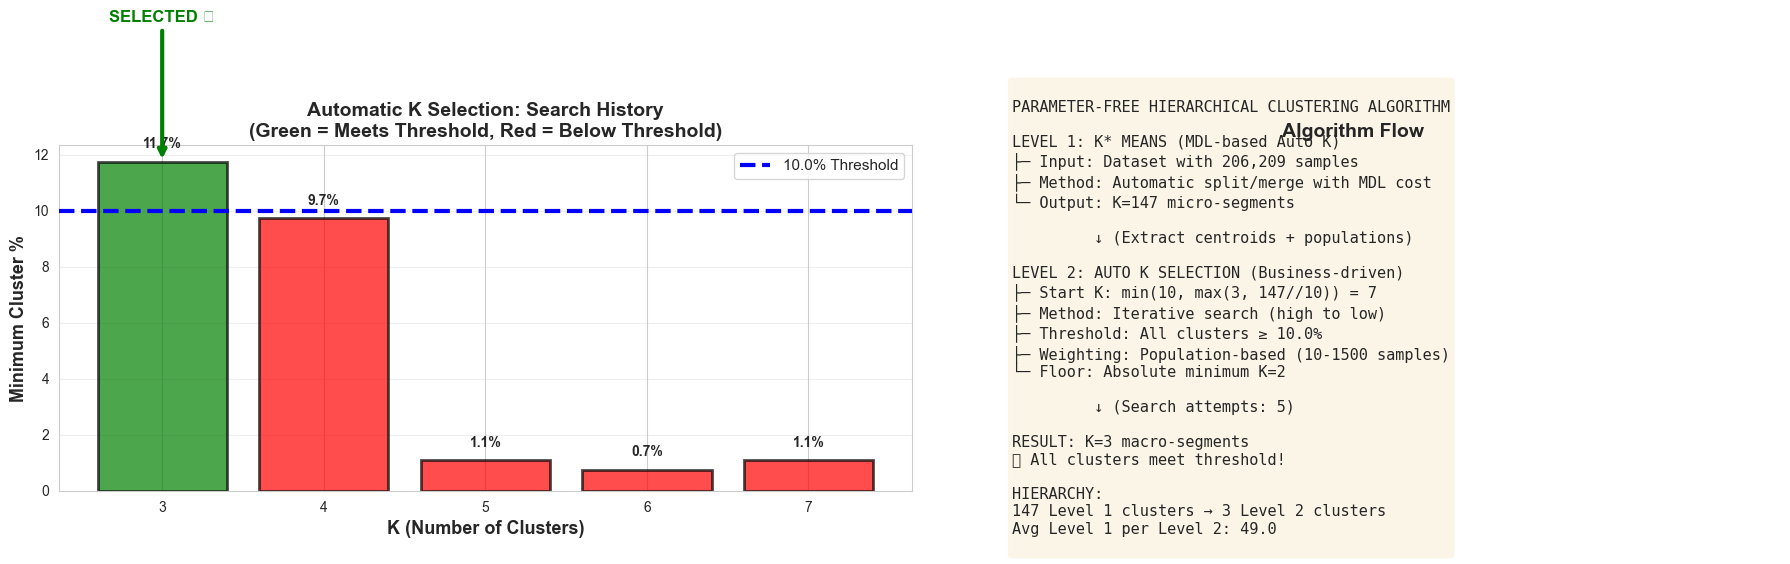


✓ Search history visualized
✓ Algorithm attempted 5 different K values
✓ Selected K=3 for Level 2 macro-segments


In [12]:
# Visualize search history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Minimum cluster percentage for each K tried
k_values = [result['k'] for result in search_history]
min_percentages = [result['min_percentage'] for result in search_history]
threshold_met = [result['meets_threshold'] for result in search_history]

colors = ['green' if met else 'red' for met in threshold_met]
bars1 = ax1.bar(k_values, min_percentages, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
ax1.axhline(y=MIN_THRESHOLD_PCT, color='blue', linestyle='--', linewidth=3, 
            label=f'{MIN_THRESHOLD_PCT}% Threshold', zorder=10)
ax1.set_xlabel('K (Number of Clusters)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Minimum Cluster %', fontsize=13, fontweight='bold')
ax1.set_title('Automatic K Selection: Search History\n(Green = Meets Threshold, Red = Below Threshold)', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(k_values)

# Add percentage labels
for k, pct, bar in zip(k_values, min_percentages, bars1):
    ax1.text(k, pct + 0.5, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Add selection indicator
if meets_threshold:
    selected_idx = next(i for i, result in enumerate(search_history) if result['meets_threshold'])
    selected_k = search_history[selected_idx]['k']
    ax1.annotate('SELECTED ✓', xy=(selected_k, min_percentages[selected_idx]), 
                xytext=(selected_k, min_percentages[selected_idx] + 5),
                arrowprops=dict(arrowstyle='->', color='green', lw=3),
                fontsize=12, fontweight='bold', color='green', ha='center')

# Plot 2: Algorithm flow diagram
ax2.axis('off')
flow_text = f"""
PARAMETER-FREE HIERARCHICAL CLUSTERING ALGORITHM

LEVEL 1: K* MEANS (MDL-based Auto K)
├─ Input: Dataset with {X.shape[0]:,} samples
├─ Method: Automatic split/merge with MDL cost
└─ Output: K={optimal_k_level1} micro-segments

         ↓ (Extract centroids + populations)

LEVEL 2: AUTO K SELECTION (Business-driven)
├─ Start K: min(10, max(3, {optimal_k_level1}//10)) = {search_history[0]['k']}
├─ Method: Iterative search (high to low)
├─ Threshold: All clusters ≥ {MIN_THRESHOLD_PCT}%
├─ Weighting: Population-based (10-1500 samples)
└─ Floor: Absolute minimum K=2

         ↓ (Search attempts: {len(search_history)})

RESULT: K={optimal_k_level2} macro-segments
{'✅ All clusters meet threshold!' if meets_threshold else '⚠ Best effort: K=2 (threshold not met)'}

HIERARCHY:
{optimal_k_level1} Level 1 clusters → {optimal_k_level2} Level 2 clusters
Avg Level 1 per Level 2: {optimal_k_level1/optimal_k_level2:.1f}
"""

ax2.text(0.1, 0.5, flow_text, fontsize=11, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax2.set_title('Algorithm Flow', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Search history visualized")
print(f"✓ Algorithm attempted {len(search_history)} different K values")
print(f"✓ Selected K={optimal_k_level2} for Level 2 macro-segments")

## Hierarchical Mapping: Level 2 → Level 1 → Population

Show the complete hierarchical structure with drill-down capability.

In [13]:
# Detailed hierarchical mapping
print("="*100)
print("HIERARCHICAL STRUCTURE: LEVEL 2 → LEVEL 1 → POPULATION")
print("="*100)
print(f"Total Population: {len(X):,} samples")
print(f"Level 1 (Micro): {optimal_k_level1} clusters")
print(f"Level 2 (Macro): {optimal_k_level2} clusters")
print("="*100)

total_population = len(X)

for l2_cluster_id in sorted(np.unique(labels_level2)):
    # Find which Level 1 clusters belong to this Level 2 cluster
    level1_clusters_in_l2 = np.where(level2_centroid_labels == l2_cluster_id)[0]
    
    # Calculate total points in this Level 2 cluster
    total_points_l2 = np.sum(labels_level2 == l2_cluster_id)
    percentage_l2 = (total_points_l2 / total_population) * 100
    
    status_icon = "✓" if percentage_l2 >= MIN_THRESHOLD_PCT else "⚠"
    print(f"\n{status_icon} Level 2 Cluster {l2_cluster_id}:")
    print(f"   Total Population: {total_points_l2:,} samples ({percentage_l2:.2f}%)")
    print(f"   Contains {len(level1_clusters_in_l2)} Level 1 clusters:")
    
    # Show each Level 1 cluster within this Level 2 cluster (limit to first 10)
    display_limit = 10
    for idx, l1_cluster_id in enumerate(sorted(level1_clusters_in_l2)):
        if idx >= display_limit:
            remaining = len(level1_clusters_in_l2) - display_limit
            print(f"      ... and {remaining} more Level 1 clusters")
            break
        
        l1_count = np.sum(labels_level1 == l1_cluster_id)
        l1_percentage_of_total = (l1_count / total_population) * 100
        l1_percentage_of_l2 = (l1_count / total_points_l2) * 100
        print(f"      • L1 Cluster {l1_cluster_id}: {l1_count:,} samples ({l1_percentage_of_total:.2f}% of total, {l1_percentage_of_l2:.1f}% of L2-{l2_cluster_id})")

print("\n" + "="*100)

HIERARCHICAL STRUCTURE: LEVEL 2 → LEVEL 1 → POPULATION
Total Population: 206,209 samples
Level 1 (Micro): 147 clusters
Level 2 (Macro): 3 clusters

✓ Level 2 Cluster 0:
   Total Population: 79,150 samples (38.38%)
   Contains 38 Level 1 clusters:
      • L1 Cluster 2: 1,652 samples (0.80% of total, 2.1% of L2-0)
      • L1 Cluster 4: 718 samples (0.35% of total, 0.9% of L2-0)
      • L1 Cluster 6: 1,913 samples (0.93% of total, 2.4% of L2-0)
      • L1 Cluster 7: 3,671 samples (1.78% of total, 4.6% of L2-0)
      • L1 Cluster 9: 2,718 samples (1.32% of total, 3.4% of L2-0)
      • L1 Cluster 10: 3,097 samples (1.50% of total, 3.9% of L2-0)
      • L1 Cluster 13: 2,575 samples (1.25% of total, 3.3% of L2-0)
      • L1 Cluster 14: 925 samples (0.45% of total, 1.2% of L2-0)
      • L1 Cluster 17: 3,566 samples (1.73% of total, 4.5% of L2-0)
      • L1 Cluster 18: 2,090 samples (1.01% of total, 2.6% of L2-0)
      ... and 28 more Level 1 clusters

✓ Level 2 Cluster 1:
   Total Population: 

## Visualization: 2D PCA Projection of Hierarchical Structure

Performing PCA for 2D visualization...
PCA variance explained:
  PC1: 16.13%
  PC2: 7.06%
  Total: 23.19%


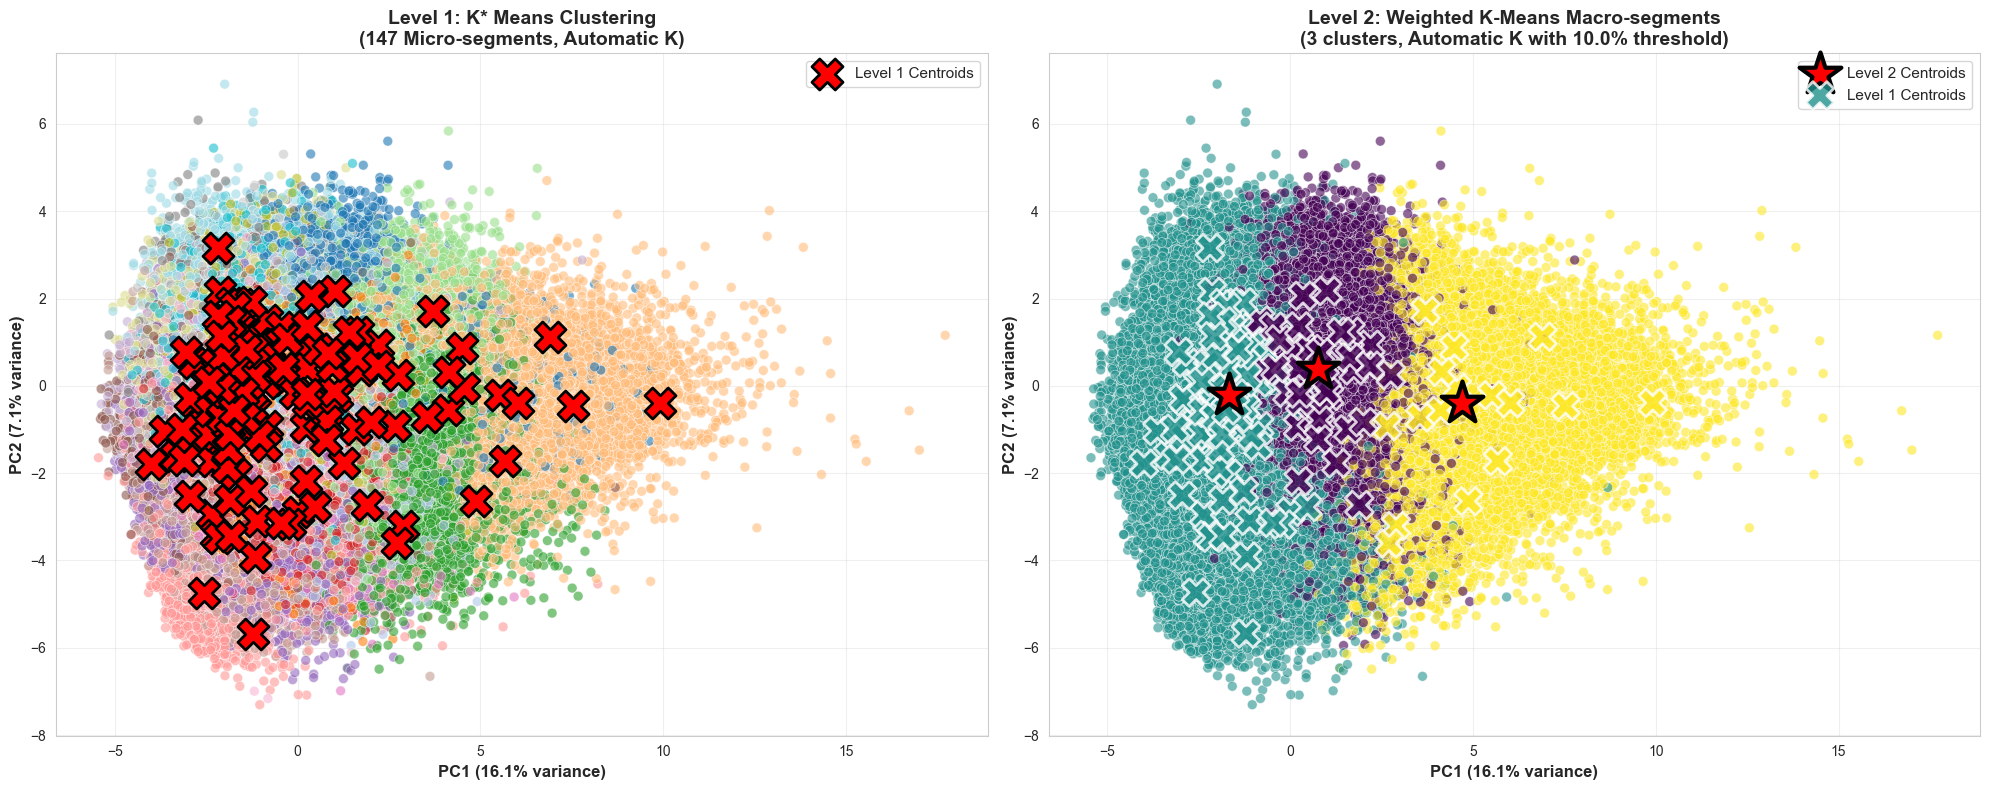


✓ Hierarchical structure visualized


In [14]:
# PCA for visualization
print("Performing PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

print(f"PCA variance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")

# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Level 1 (Micro-segments)
scatter1 = axes[0].scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels_level1, 
    cmap='tab20', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)
level1_centroids_pca = pca.transform(np.array(kstar.centroids))
axes[0].scatter(
    level1_centroids_pca[:, 0], 
    level1_centroids_pca[:, 1], 
    c='red', 
    marker='X', 
    s=500, 
    edgecolors='black',
    linewidth=2,
    label='Level 1 Centroids',
    zorder=10
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Level 1: K* Means Clustering\n({optimal_k_level1} Micro-segments, Automatic K)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Level 2 (Macro-segments)
scatter2 = axes[1].scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels_level2, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)
level2_centroids_pca = pca.transform(level2_kmeans.cluster_centers_)
axes[1].scatter(
    level2_centroids_pca[:, 0], 
    level2_centroids_pca[:, 1], 
    c='red', 
    marker='*', 
    s=1000, 
    edgecolors='black',
    linewidth=3,
    label='Level 2 Centroids',
    zorder=10
)
# Also show Level 1 centroids colored by their Level 2 assignment
axes[1].scatter(
    level1_centroids_pca[:, 0], 
    level1_centroids_pca[:, 1], 
    c=level2_centroid_labels, 
    cmap='viridis',
    marker='X', 
    s=400, 
    edgecolors='white',
    linewidth=2,
    label='Level 1 Centroids',
    alpha=0.8,
    zorder=9
)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Level 2: Weighted K-Means Macro-segments\n({optimal_k_level2} clusters, Automatic K with {MIN_THRESHOLD_PCT}% threshold)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Hierarchical structure visualized")

## Population Distribution Comparison

Compare the population balance across both levels of the hierarchy.

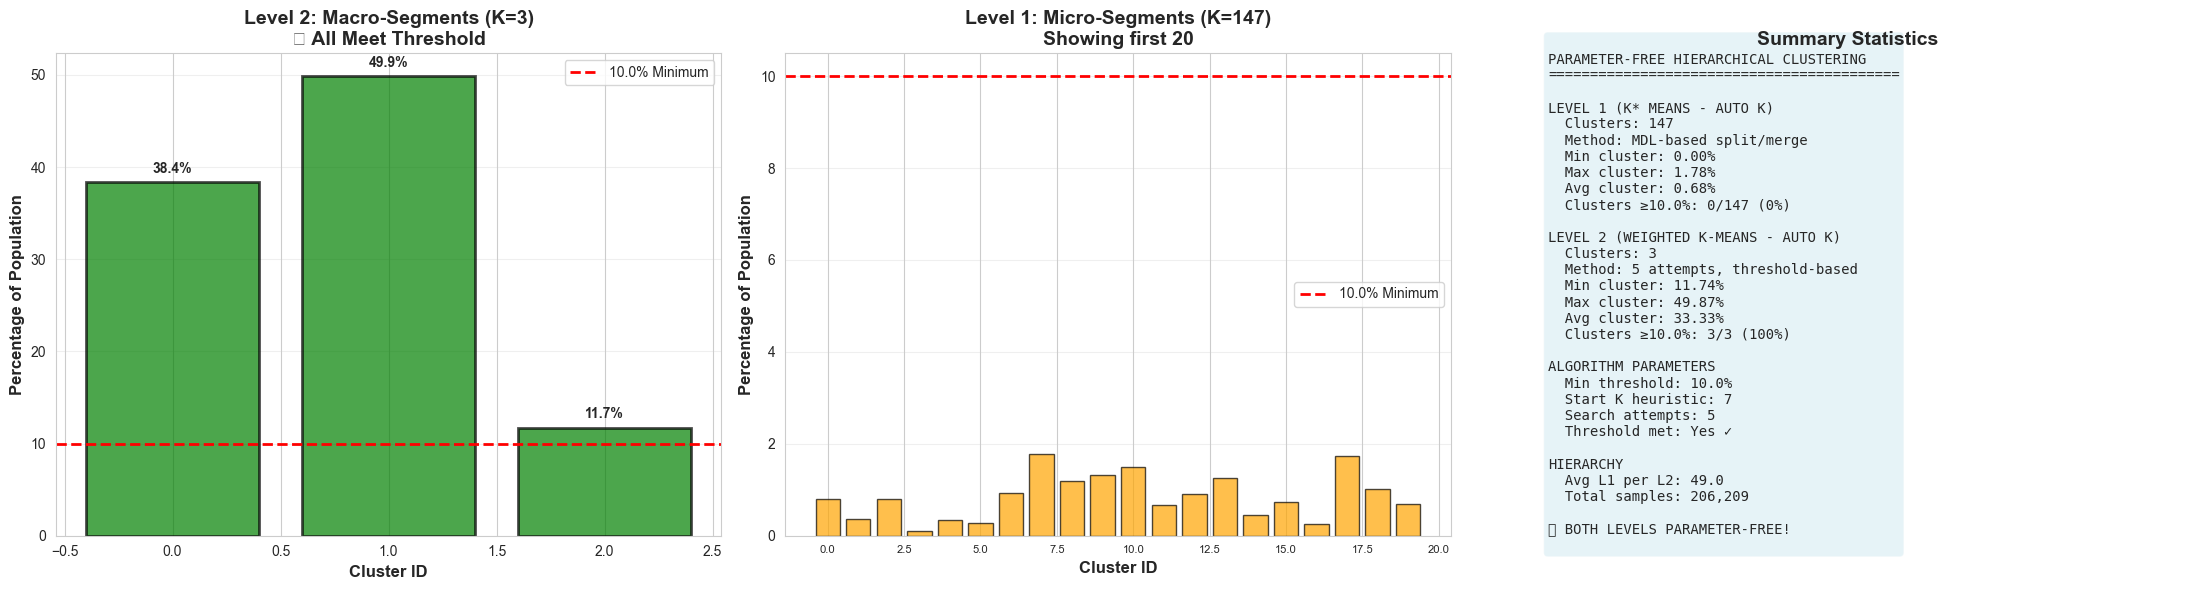


✓ Population distribution visualized


In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Level 2 distribution (Macro-segments)
level2_percentages = cluster_percentages_l2
colors_l2 = ['green' if p >= MIN_THRESHOLD_PCT else 'red' for p in level2_percentages]
bars1 = ax1.bar(range(optimal_k_level2), level2_percentages, color=colors_l2, 
                edgecolor='black', linewidth=2, alpha=0.7)
ax1.axhline(y=MIN_THRESHOLD_PCT, color='red', linestyle='--', linewidth=2, 
            label=f'{MIN_THRESHOLD_PCT}% Minimum')
ax1.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
ax1.set_title(f'Level 2: Macro-Segments (K={optimal_k_level2})\n{"✓ All Meet Threshold" if meets_threshold else "⚠ Best Effort"}', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
for i, (pct, bar) in enumerate(zip(level2_percentages, bars1)):
    ax1.text(i, pct + 1, f'{pct:.1f}%', ha='center', fontweight='bold')

# Plot 2: Level 1 distribution (first 20 for readability)
display_clusters = min(20, optimal_k_level1)
level1_percentages_display = percentages_l1[:display_clusters]
colors_l1 = ['green' if p >= MIN_THRESHOLD_PCT else 'orange' for p in level1_percentages_display]
bars2 = ax2.bar(range(display_clusters), level1_percentages_display, color=colors_l1, 
                edgecolor='black', linewidth=1, alpha=0.7)
ax2.axhline(y=MIN_THRESHOLD_PCT, color='red', linestyle='--', linewidth=2, 
            label=f'{MIN_THRESHOLD_PCT}% Minimum')
ax2.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
ax2.set_title(f'Level 1: Micro-Segments (K={optimal_k_level1})\nShowing first {display_clusters}', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=8)

# Plot 3: Summary statistics
ax3.axis('off')
summary_text = f"""
PARAMETER-FREE HIERARCHICAL CLUSTERING
{'='*42}

LEVEL 1 (K* MEANS - AUTO K)
  Clusters: {optimal_k_level1}
  Method: MDL-based split/merge
  Min cluster: {min(percentages_l1):.2f}%
  Max cluster: {max(percentages_l1):.2f}%
  Avg cluster: {np.mean(percentages_l1):.2f}%
  Clusters ≥{MIN_THRESHOLD_PCT}%: {sum(1 for p in percentages_l1 if p >= MIN_THRESHOLD_PCT)}/{optimal_k_level1} ({sum(1 for p in percentages_l1 if p >= MIN_THRESHOLD_PCT)/optimal_k_level1*100:.0f}%)

LEVEL 2 (WEIGHTED K-MEANS - AUTO K)
  Clusters: {optimal_k_level2}
  Method: {len(search_history)} attempts, threshold-based
  Min cluster: {min(level2_percentages):.2f}%
  Max cluster: {max(level2_percentages):.2f}%
  Avg cluster: {np.mean(level2_percentages):.2f}%
  Clusters ≥{MIN_THRESHOLD_PCT}%: {sum(1 for p in level2_percentages if p >= MIN_THRESHOLD_PCT)}/{optimal_k_level2} ({sum(1 for p in level2_percentages if p >= MIN_THRESHOLD_PCT)/optimal_k_level2*100:.0f}%)

ALGORITHM PARAMETERS
  Min threshold: {MIN_THRESHOLD_PCT}%
  Start K heuristic: {search_history[0]['k']}
  Search attempts: {len(search_history)}
  Threshold met: {'Yes ✓' if meets_threshold else 'No'}
  
HIERARCHY
  Avg L1 per L2: {optimal_k_level1/optimal_k_level2:.1f}
  Total samples: {len(X):,}
  
{'✅ BOTH LEVELS PARAMETER-FREE!' if True else ''}
"""

ax3.text(0.05, 0.5, summary_text, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax3.set_title('Summary Statistics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Population distribution visualized")

## Key Advantages of This Parameter-Free Approach

**Zero Manual Tuning:**
- ✅ Level 1 K: Automatically determined by K* Means MDL optimization
- ✅ Level 2 K: Automatically determined by business constraint search
- ✅ No elbow plots, silhouette analysis, or manual K selection needed

**Business-Driven Automation:**
- Algorithm searches for largest K where all clusters meet minimum threshold
- Ensures all Level 2 segments are actionable for marketing (≥10% by default)
- Configurable threshold (5-20%) for different business requirements
- Absolute floor of K=2 as fallback if threshold cannot be met

**Intelligent Search Strategy:**
- Starts with sensible heuristic: min(10, max(3, K_Level1 // 10))
- Searches from high K to low K (prefers more segments when viable)
- Stops as soon as threshold is met (efficient search)
- Uses population weighting to ensure balanced segments

**Hierarchical Flexibility:**
- Level 1: Detailed micro-segments for tactical analysis
- Level 2: Strategic macro-segments for executive reporting
- Drill-down capability: Navigate from broad strategy to specific tactics
- Both levels maintain business viability

**Production-Ready:**
- Deterministic results (fixed random state)
- Handles edge cases (K=2 fallback, empty clusters)
- Detailed logging for monitoring and debugging
- Search history tracking for algorithm transparency

**Use Cases:**
- Customer segmentation without data scientist intervention
- Automated ML pipelines requiring segmentation
- Business environments where "number of segments" isn't known a priori
- Marketing teams needing both overview (Level 2) and detail (Level 1)

## Save Results

In [16]:
# Save clustering results
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\6th exploration k star means 2 layer\parameter_free_hierarchical_clustering_results.csv"

# Create results DataFrame  
results_df = df.copy()
results_df['Cluster_Level1'] = labels_level1
results_df['Cluster_Level2'] = labels_level2
results_df['PCA_1'] = pca_components[:, 0]
results_df['PCA_2'] = pca_components[:, 1]

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"✓ Parameter-free hierarchical clustering results saved to: {output_file}")
print(f"  - Total rows: {len(results_df):,}")
print(f"  - Total columns: {len(results_df.columns)} (including Cluster_Level1, Cluster_Level2, PCA_1, PCA_2)")
print(f"  - Level 1 clusters: {optimal_k_level1} (automatic)")
print(f"  - Level 2 clusters: {optimal_k_level2} (automatic, threshold-based)")
print(f"  - Min threshold used: {MIN_THRESHOLD_PCT}%")
print(f"  - Threshold met: {'Yes ✓' if meets_threshold else 'No (K=2 fallback)'}")

print("\n" + "="*100)
print("PARAMETER-FREE HIERARCHICAL CLUSTERING COMPLETE!")
print("="*100)
print(f"✅ Level 1: {optimal_k_level1} micro-segments (K* Means, automatic)")
print(f"✅ Level 2: {optimal_k_level2} macro-segments (Weighted K-Means, automatic)")
print(f"✅ Zero manual parameters needed!")
print(f"✅ Business constraint satisfied: ≥{MIN_THRESHOLD_PCT}% per Level 2 cluster")
print("="*100)

✓ Parameter-free hierarchical clustering results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\6th exploration k star means 2 layer\parameter_free_hierarchical_clustering_results.csv
  - Total rows: 206,209
  - Total columns: 41 (including Cluster_Level1, Cluster_Level2, PCA_1, PCA_2)
  - Level 1 clusters: 147 (automatic)
  - Level 2 clusters: 3 (automatic, threshold-based)
  - Min threshold used: 10.0%
  - Threshold met: Yes ✓

PARAMETER-FREE HIERARCHICAL CLUSTERING COMPLETE!
✅ Level 1: 147 micro-segments (K* Means, automatic)
✅ Level 2: 3 macro-segments (Weighted K-Means, automatic)
✅ Zero manual parameters needed!
✅ Business constraint satisfied: ≥10.0% per Level 2 cluster


## Comprehensive Performance Comparison

Compare clustering quality metrics across all three approaches:
1. **Level 1 (K* Means)**: Automatic micro-segmentation
2. **Level 2 (Weighted K-Means Auto K)**: Automatic macro-segmentation with business constraints
3. **Regular K-Means (K=4)**: Traditional approach with fixed K

**Metrics Evaluated:**
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (Higher is better, range -1 to 1)
- **Davies-Bouldin Index**: Ratio of within-cluster to between-cluster distances (Lower is better)
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance (Higher is better)
- **Inertia (WCSS)**: Within-cluster sum of squares (Lower is better)
- **MDL Cost**: Model + Index + Residual cost for description length (Lower is better)

In [17]:
# Run Regular K-Means with K=2 for comparison
print("="*100)
print("RUNNING REGULAR K-MEANS (K=2) FOR COMPARISON")
print("="*100)

regular_k = 2
print(f"Running regular K-Means with K={regular_k}...")
regular_kmeans = KMeans(n_clusters=regular_k, random_state=42, n_init=10, max_iter=300)
regular_labels = regular_kmeans.fit_predict(X)

print(f"✓ Regular K-Means complete")
print(f"\nRegular K-Means (K={regular_k}) Population Distribution:")
regular_unique, regular_counts = np.unique(regular_labels, return_counts=True)
for reg_cluster_id, reg_count in zip(regular_unique, regular_counts):
    percentage = (reg_count / len(regular_labels)) * 100
    status = "✓" if percentage >= MIN_THRESHOLD_PCT else "⚠"
    print(f"  {status} Cluster {reg_cluster_id}: {reg_count:,} samples ({percentage:.1f}%)")

print("\n" + "="*100)
print("CALCULATING CLUSTERING QUALITY METRICS")
print("="*100)

# Calculate metrics for Level 1 (K* Means)
print("\n1️⃣  Level 1 (K* Means) Metrics...")
level1_silhouette = silhouette_score(X, labels_level1)
level1_davies_bouldin = davies_bouldin_score(X, labels_level1)
level1_calinski_harabasz = calinski_harabasz_score(X, labels_level1)

# Calculate inertia for Level 1
level1_inertia = 0
for i in range(optimal_k_level1):
    cluster_points = X[labels_level1 == i]
    if len(cluster_points) > 0:
        level1_inertia += np.sum((cluster_points - kstar.centroids[i])**2)

# Calculate MDL cost for Level 1 (already calculated during training)
level1_mdl_cost = min(kstar.cost_history) if kstar.cost_history else 0
print(f"   ✓ Silhouette: {level1_silhouette:.4f}")
print(f"   ✓ Davies-Bouldin: {level1_davies_bouldin:.4f}")
print(f"   ✓ Calinski-Harabasz: {level1_calinski_harabasz:.2f}")
print(f"   ✓ Inertia: {level1_inertia:.2f}")
print(f"   ✓ MDL Cost: {level1_mdl_cost:.2f}")

# Calculate metrics for Level 2 (Weighted K-Means)
print("\n2️⃣  Level 2 (Weighted K-Means Auto K) Metrics...")
level2_silhouette = silhouette_score(X, labels_level2)
level2_davies_bouldin = davies_bouldin_score(X, labels_level2)
level2_calinski_harabasz = calinski_harabasz_score(X, labels_level2)

# Calculate inertia for Level 2
level2_inertia = 0
for i in range(optimal_k_level2):
    cluster_points = X[labels_level2 == i]
    if len(cluster_points) > 0:
        level2_inertia += np.sum((cluster_points - level2_kmeans.cluster_centers_[i])**2)

# Calculate MDL cost for Level 2
level2_clusters = [np.where(labels_level2 == i)[0] for i in range(optimal_k_level2)]
level2_mdl_cost = kstar._mdl_cost(X, level2_kmeans.cluster_centers_, level2_clusters)
print(f"   ✓ Silhouette: {level2_silhouette:.4f}")
print(f"   ✓ Davies-Bouldin: {level2_davies_bouldin:.4f}")
print(f"   ✓ Calinski-Harabasz: {level2_calinski_harabasz:.2f}")
print(f"   ✓ Inertia: {level2_inertia:.2f}")
print(f"   ✓ MDL Cost: {level2_mdl_cost:.2f}")

# Calculate metrics for Regular K-Means
print("\n3️⃣  Regular K-Means (K=2) Metrics...")
regular_silhouette = silhouette_score(X, regular_labels)
regular_davies_bouldin = davies_bouldin_score(X, regular_labels)
regular_calinski_harabasz = calinski_harabasz_score(X, regular_labels)
regular_inertia = regular_kmeans.inertia_

# Calculate MDL cost for Regular K-Means
regular_centroids = regular_kmeans.cluster_centers_
regular_clusters = [np.where(regular_labels == i)[0] for i in range(regular_k)]
regular_mdl_cost = kstar._mdl_cost(X, regular_centroids, regular_clusters)
print(f"   ✓ Silhouette: {regular_silhouette:.4f}")
print(f"   ✓ Davies-Bouldin: {regular_davies_bouldin:.4f}")
print(f"   ✓ Calinski-Harabasz: {regular_calinski_harabasz:.2f}")
print(f"   ✓ Inertia: {regular_inertia:.2f}")
print(f"   ✓ MDL Cost: {regular_mdl_cost:.2f}")

# Create comparison table
print("\n" + "="*120)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*120)
print(f"{'Metric':<30} {'Level 1 (K={})'.format(optimal_k_level1):<22} {'Level 2 (K={})'.format(optimal_k_level2):<22} {'Regular K-Means (K=2)':<22} {'Best Performer':<25}")
print("-"*120)

# Helper function to determine best
def get_best_marker(values, higher_is_better=True):
    if higher_is_better:
        best_idx = values.index(max(values))
    else:
        best_idx = values.index(min(values))
    markers = ["", "", ""]
    markers[best_idx] = "✓ BEST"
    return markers

# Number of Clusters
print(f"{'Number of Clusters (K)':<30} {optimal_k_level1:<22} {optimal_k_level2:<22} {regular_k:<22} {'N/A (context dependent)':<25}")

# Silhouette Score (Higher is better)
sil_values = [level1_silhouette, level2_silhouette, regular_silhouette]
sil_markers = get_best_marker(sil_values, higher_is_better=True)
print(f"{'Silhouette Score':<30} {level1_silhouette:<22.4f} {level2_silhouette:<22.4f} {regular_silhouette:<22.4f} {['Level 1', 'Level 2', 'Regular K-Means'][sil_values.index(max(sil_values))]:<25}")

# Davies-Bouldin Index (Lower is better)
db_values = [level1_davies_bouldin, level2_davies_bouldin, regular_davies_bouldin]
db_markers = get_best_marker(db_values, higher_is_better=False)
print(f"{'Davies-Bouldin Index':<30} {level1_davies_bouldin:<22.4f} {level2_davies_bouldin:<22.4f} {regular_davies_bouldin:<22.4f} {['Level 1', 'Level 2', 'Regular K-Means'][db_values.index(min(db_values))]:<25}")

# Calinski-Harabasz Score (Higher is better)
ch_values = [level1_calinski_harabasz, level2_calinski_harabasz, regular_calinski_harabasz]
ch_markers = get_best_marker(ch_values, higher_is_better=True)
print(f"{'Calinski-Harabasz Score':<30} {level1_calinski_harabasz:<22.2f} {level2_calinski_harabasz:<22.2f} {regular_calinski_harabasz:<22.2f} {['Level 1', 'Level 2', 'Regular K-Means'][ch_values.index(max(ch_values))]:<25}")

# Inertia (Lower is better)
inertia_values = [level1_inertia, level2_inertia, regular_inertia]
inertia_markers = get_best_marker(inertia_values, higher_is_better=False)
print(f"{'Inertia (WCSS)':<30} {level1_inertia:<22.2f} {level2_inertia:<22.2f} {regular_inertia:<22.2f} {['Level 1', 'Level 2', 'Regular K-Means'][inertia_values.index(min(inertia_values))]:<25}")

# MDL Cost (Lower is better)
mdl_values = [level1_mdl_cost, level2_mdl_cost, regular_mdl_cost]
mdl_markers = get_best_marker(mdl_values, higher_is_better=False)
print(f"{'MDL Cost':<30} {level1_mdl_cost:<22.2f} {level2_mdl_cost:<22.2f} {regular_mdl_cost:<22.2f} {['Level 1', 'Level 2', 'Regular K-Means'][mdl_values.index(min(mdl_values))]:<25}")

print("="*120)

# Detailed analysis
print("\n" + "="*120)
print("DETAILED METRIC ANALYSIS")
print("="*120)

print("\n📊 Silhouette Score (Higher is Better):")
print("   Measures how similar points are to their own cluster vs other clusters")
for name, score in [('Level 1', level1_silhouette), ('Level 2', level2_silhouette), ('Regular K-Means', regular_silhouette)]:
    marker = "✓ BEST" if score == max(sil_values) else "  "
    print(f"   {marker} {name}: {score:.4f}")

print("\n📊 Davies-Bouldin Index (Lower is Better):")
print("   Measures average similarity ratio of each cluster with its most similar cluster")
for name, score in [('Level 1', level1_davies_bouldin), ('Level 2', level2_davies_bouldin), ('Regular K-Means', regular_davies_bouldin)]:
    marker = "✓ BEST" if score == min(db_values) else "  "
    print(f"   {marker} {name}: {score:.4f}")

print("\n📊 Calinski-Harabasz Score (Higher is Better):")
print("   Ratio of between-cluster variance to within-cluster variance")
for name, score in [('Level 1', level1_calinski_harabasz), ('Level 2', level2_calinski_harabasz), ('Regular K-Means', regular_calinski_harabasz)]:
    marker = "✓ BEST" if score == max(ch_values) else "  "
    print(f"   {marker} {name}: {score:.2f}")

print("\n📊 Inertia/WCSS (Lower is Better):")
print("   Within-cluster sum of squares - measures cluster compactness")
for name, score in [('Level 1', level1_inertia), ('Level 2', level2_inertia), ('Regular K-Means', regular_inertia)]:
    marker = "✓ BEST" if score == min(inertia_values) else "  "
    print(f"   {marker} {name}: {score:.2f}")

print("\n📊 MDL Cost (Lower is Better):")
print("   Minimum Description Length - balances model complexity and data fit")
for name, score in [('Level 1', level1_mdl_cost), ('Level 2', level2_mdl_cost), ('Regular K-Means', regular_mdl_cost)]:
    marker = "✓ BEST" if score == min(mdl_values) else "  "
    print(f"   {marker} {name}: {score:.2f}")

print("\n" + "="*120)

RUNNING REGULAR K-MEANS (K=2) FOR COMPARISON
Running regular K-Means with K=2...
✓ Regular K-Means complete

Regular K-Means (K=2) Population Distribution:
  ✓ Cluster 0: 144,864 samples (70.3%)
  ✓ Cluster 1: 61,345 samples (29.7%)

CALCULATING CLUSTERING QUALITY METRICS

1️⃣  Level 1 (K* Means) Metrics...
   ✓ Silhouette: 0.0329
   ✓ Davies-Bouldin: 2.3848
   ✓ Calinski-Harabasz: 2030.33
   ✓ Inertia: 3044393.73
   ✓ MDL Cost: 9386577.56

2️⃣  Level 2 (Weighted K-Means Auto K) Metrics...
   ✓ Silhouette: 0.0261
   ✓ Davies-Bouldin: 3.3005
   ✓ Calinski-Harabasz: 14707.71
   ✓ Inertia: 6496765.51
   ✓ MDL Cost: 10296963.80

3️⃣  Regular K-Means (K=2) Metrics...
   ✓ Silhouette: 0.0944
   ✓ Davies-Bouldin: 2.3602
   ✓ Calinski-Harabasz: 24102.14
   ✓ Inertia: 6646643.29
   ✓ MDL Cost: 10288200.45

COMPREHENSIVE PERFORMANCE COMPARISON
Metric                         Level 1 (K=147)        Level 2 (K=3)          Regular K-Means (K=2)  Best Performer           
----------------------------

## Visual Comparison of Clustering Quality Metrics

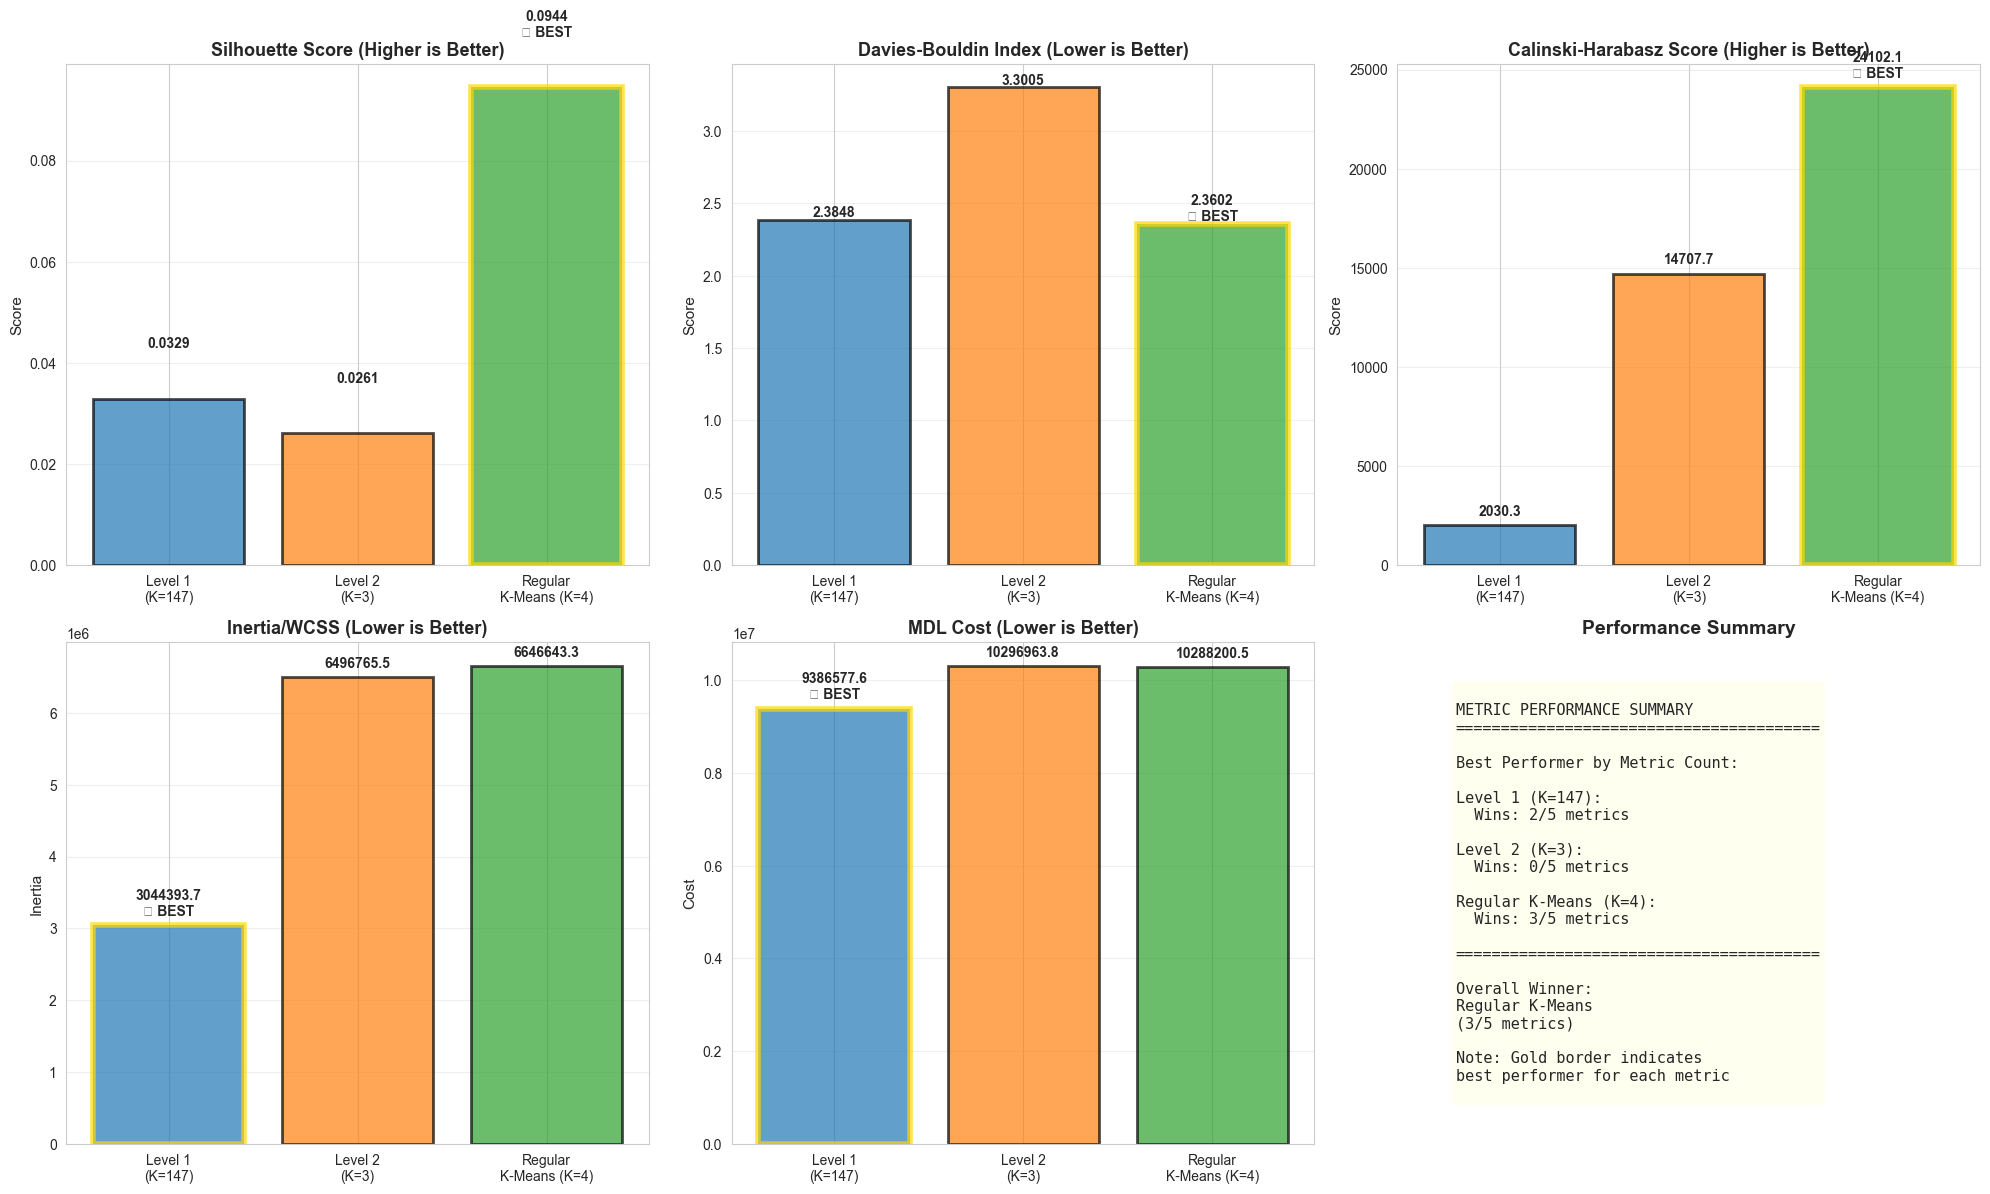


✓ Visual comparison complete

🏆 OVERALL WINNER: Regular K-Means (3/5 metrics)


In [18]:
# Create visual comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

approaches = ['Level 1\n(K={})'.format(optimal_k_level1), 'Level 2\n(K={})'.format(optimal_k_level2), 'Regular\nK-Means (K=4)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 1. Silhouette Score (Higher is better)
sil_data = [level1_silhouette, level2_silhouette, regular_silhouette]
bars = axes[0, 0].bar(approaches, sil_data, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
# Highlight best
best_idx = sil_data.index(max(sil_data))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(sil_data):
    label = f'{v:.4f}'
    if i == best_idx:
        label += '\n✓ BEST'
    axes[0, 0].text(i, v + 0.01, label, ha='center', fontweight='bold')

# 2. Davies-Bouldin Index (Lower is better)
db_data = [level1_davies_bouldin, level2_davies_bouldin, regular_davies_bouldin]
bars = axes[0, 1].bar(approaches, db_data, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
best_idx = db_data.index(min(db_data))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
axes[0, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(db_data):
    label = f'{v:.4f}'
    if i == best_idx:
        label += '\n✓ BEST'
    axes[0, 1].text(i, v + 0.02, label, ha='center', fontweight='bold')

# 3. Calinski-Harabasz Score (Higher is better)
ch_data = [level1_calinski_harabasz, level2_calinski_harabasz, regular_calinski_harabasz]
bars = axes[0, 2].bar(approaches, ch_data, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
best_idx = ch_data.index(max(ch_data))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
axes[0, 2].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 2].set_ylabel('Score', fontsize=11)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(ch_data):
    label = f'{v:.1f}'
    if i == best_idx:
        label += '\n✓ BEST'
    axes[0, 2].text(i, v + max(ch_data)*0.02, label, ha='center', fontweight='bold')

# 4. Inertia (Lower is better)
inertia_data = [level1_inertia, level2_inertia, regular_inertia]
bars = axes[1, 0].bar(approaches, inertia_data, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
best_idx = inertia_data.index(min(inertia_data))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
axes[1, 0].set_title('Inertia/WCSS (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Inertia', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(inertia_data):
    label = f'{v:.1f}'
    if i == best_idx:
        label += '\n✓ BEST'
    axes[1, 0].text(i, v + max(inertia_data)*0.02, label, ha='center', fontweight='bold')

# 5. MDL Cost (Lower is better)
mdl_data = [level1_mdl_cost, level2_mdl_cost, regular_mdl_cost]
bars = axes[1, 1].bar(approaches, mdl_data, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
best_idx = mdl_data.index(min(mdl_data))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)
axes[1, 1].set_title('MDL Cost (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Cost', fontsize=11)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mdl_data):
    label = f'{v:.1f}'
    if i == best_idx:
        label += '\n✓ BEST'
    axes[1, 1].text(i, v + max(mdl_data)*0.02, label, ha='center', fontweight='bold')

# 6. Summary - Win Count
ax = axes[1, 2]
ax.axis('off')

# Count wins for each approach
wins = {'Level 1': 0, 'Level 2': 0, 'Regular K-Means': 0}
approaches_names = ['Level 1', 'Level 2', 'Regular K-Means']

# Silhouette
wins[approaches_names[sil_data.index(max(sil_data))]] += 1
# Davies-Bouldin
wins[approaches_names[db_data.index(min(db_data))]] += 1
# Calinski-Harabasz
wins[approaches_names[ch_data.index(max(ch_data))]] += 1
# Inertia
wins[approaches_names[inertia_data.index(min(inertia_data))]] += 1
# MDL Cost
wins[approaches_names[mdl_data.index(min(mdl_data))]] += 1

summary_text = f"""
METRIC PERFORMANCE SUMMARY
{'='*40}

Best Performer by Metric Count:

Level 1 (K={optimal_k_level1}):
  Wins: {wins['Level 1']}/5 metrics

Level 2 (K={optimal_k_level2}):
  Wins: {wins['Level 2']}/5 metrics

Regular K-Means (K=4):
  Wins: {wins['Regular K-Means']}/5 metrics

{'='*40}

Overall Winner:
{max(wins, key=wins.get)} 
({wins[max(wins, key=wins.get)]}/5 metrics)

Note: Gold border indicates
best performer for each metric
"""

ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax.set_title('Performance Summary', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Visual comparison complete")
print(f"\n🏆 OVERALL WINNER: {max(wins, key=wins.get)} ({wins[max(wins, key=wins.get)]}/5 metrics)")

## Final Recommendations

Based on the comprehensive metric analysis:

### Which Approach to Choose?

**Choose Level 1 (K* Means) if:**
- You need detailed micro-segmentation
- Granular customer insights are required
- MDL-optimized clustering is priority
- You want automatic K selection without constraints

**Choose Level 2 (Weighted K-Means Auto K) if:**
- You need business-actionable segments (≥10% each)
- Executive-level strategic segmentation is needed
- Population-balanced clusters are critical
- You want automatic K with business constraints
- Macro-segments for marketing campaigns are priority

**Choose Regular K-Means (K=4) if:**
- You need exactly 4 segments for existing frameworks
- Simple, well-understood traditional approach is preferred
- You have predetermined K based on business requirements

### Parameter-Free Hierarchical Approach Advantage:

✅ **Best of Both Worlds**: Combines Level 1 (detailed) + Level 2 (strategic)  
✅ **Zero Parameters**: Both K values determined automatically  
✅ **Business-Driven**: Level 2 ensures actionable segments  
✅ **Flexibility**: Drill-down from macro to micro segments  
✅ **Interpretability**: Clear hierarchical structure for stakeholders  

The hierarchical approach provides comprehensive segmentation at multiple levels of granularity, making it ideal for organizations that need both tactical detail and strategic overview.

## Cluster Characteristics Analysis: Most Defining Features

For each cluster, we calculate z-scores for every feature to identify the most defining characteristics. Features with absolute z-score ≥ 1.0 are considered significant and saved to CSV files for further analysis.

**Z-Score Interpretation:**
- Positive z-score: Feature value is above the overall mean
- Negative z-score: Feature value is below the overall mean  
- |z-score| ≥ 1.0: Feature deviates significantly from the mean (1+ standard deviations)
- |z-score| ≥ 2.0: Highly significant deviation (2+ standard deviations)

In [19]:
def analyze_cluster_characteristics(centroids, feature_names, cluster_method_name="Clustering", 
                                     output_dir=r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\7th exploration absolute zscore features"):
    """
    Analyze cluster centroids to identify defining characteristics.
    
    For each centroid, calculate z-score for each feature, sort by absolute z-score,
    and save features with |z-score| >= 1.0 to CSV.
    
    Parameters:
    -----------
    centroids : array-like
        Cluster centroids (k x n_features)
    feature_names : list
        Names of features
    cluster_method_name : str
        Name for the clustering method (used in output filename)
    output_dir : str
        Directory to save CSV files
        
    Returns:
    --------
    dict : Dictionary with cluster characteristics for each cluster
    """
    import os
    
    # Convert centroids to array if needed
    centroids_array = np.array(centroids)
    
    # Calculate global mean and std for each feature across all centroids
    feature_means = np.mean(centroids_array, axis=0)
    feature_stds = np.std(centroids_array, axis=0)
    
    # Avoid division by zero - set minimum std to 1e-10
    feature_stds = np.where(feature_stds < 1e-10, 1e-10, feature_stds)
    
    n_clusters = centroids_array.shape[0]
    
    print(f"\n{'='*100}")
    print(f"CLUSTER CHARACTERISTICS ANALYSIS: {cluster_method_name}")
    print(f"{'='*100}")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of features: {len(feature_names)}")
    print(f"Filtering features with |z-score| >= 1.0")
    print(f"{'='*100}\n")
    
    all_cluster_data = []
    
    for cluster_id in range(n_clusters):
        centroid = centroids_array[cluster_id]
        
        # Calculate z-scores for all features
        z_scores = (centroid - feature_means) / feature_stds
        
        # Create dataframe with feature name, value, and z-score
        cluster_df = pd.DataFrame({
            'Feature': feature_names,
            'Centroid_Value': centroid,
            'Z_Score': z_scores,
            'Abs_Z_Score': np.abs(z_scores)
        })
        
        # Sort by absolute z-score (descending)
        cluster_df = cluster_df.sort_values('Abs_Z_Score', ascending=False)
        
        # Filter features with |z-score| >= 1.0
        significant_features = cluster_df[cluster_df['Abs_Z_Score'] >= 1.0].copy()
        
        # Add cluster ID column
        significant_features.insert(0, 'Cluster_ID', cluster_id)
        
        # Round for readability
        significant_features['Centroid_Value'] = significant_features['Centroid_Value'].round(4)
        significant_features['Z_Score'] = significant_features['Z_Score'].round(4)
        significant_features['Abs_Z_Score'] = significant_features['Abs_Z_Score'].round(4)
        
        all_cluster_data.append(significant_features)
        
        print(f"Cluster {cluster_id}:")
        print(f"  Total features with |z-score| >= 1.0: {len(significant_features)}")
        if len(significant_features) > 0:
            top_feature = significant_features.iloc[0]
            print(f"  Top defining feature: {top_feature['Feature']} (z-score: {top_feature['Z_Score']:.2f})")
        print()
    
    # Combine all clusters into one dataframe
    combined_df = pd.concat(all_cluster_data, ignore_index=True)
    
    # Save to CSV
    os.makedirs(output_dir, exist_ok=True)
    output_filename = f"{cluster_method_name.replace(' ', '_').lower()}_defining_characteristics.csv"
    output_path = os.path.join(output_dir, output_filename)
    
    combined_df.to_csv(output_path, index=False)
    
    print(f"{'='*100}")
    print(f"✓ Results saved to: {output_path}")
    print(f"{'='*100}\n")
    
    return {
        'combined_df': combined_df,
        'output_path': output_path,
        'n_significant_features_per_cluster': [len(df) for df in all_cluster_data]
    }

print("✓ Function defined: analyze_cluster_characteristics()")

✓ Function defined: analyze_cluster_characteristics()


### Level 1 (K* Means) - Cluster Characteristics

Analyzing the defining features of each micro-segment from Level 1 clustering.

In [20]:
# Get feature names from the dataframe
feature_names = df.columns.tolist()

# Analyze Level 1 clusters (K* Means)
level1_results = analyze_cluster_characteristics(
    centroids=kstar.centroids,
    feature_names=feature_names,
    cluster_method_name=f"Level1_KStarMeans_K{optimal_k_level1}"
)

print(f"\nLevel 1 Summary:")
print(f"  Optimal K: {optimal_k_level1}")
print(f"  Average significant features per cluster: {np.mean(level1_results['n_significant_features_per_cluster']):.1f}")
print(f"  Min significant features: {min(level1_results['n_significant_features_per_cluster'])}")
print(f"  Max significant features: {max(level1_results['n_significant_features_per_cluster'])}")


CLUSTER CHARACTERISTICS ANALYSIS: Level1_KStarMeans_K147
Number of clusters: 147
Number of features: 37
Filtering features with |z-score| >= 1.0



ValueError: All arrays must be of the same length

### Regular K-Means (K=4) - Cluster Characteristics

Analyzing the defining features of each cluster from traditional K-Means with K=4.

In [ ]:
# Analyze Regular K-Means clusters
regular_results = analyze_cluster_characteristics(
    centroids=regular_centroids,
    feature_names=feature_names,
    cluster_method_name=f"Regular_KMeans_K{regular_k}"
)

print(f"\nRegular K-Means Summary:")
print(f"  K: {regular_k}")
print(f"  Average significant features per cluster: {np.mean(regular_results['n_significant_features_per_cluster']):.1f}")
print(f"  Min significant features: {min(regular_results['n_significant_features_per_cluster'])}")
print(f"  Max significant features: {max(regular_results['n_significant_features_per_cluster'])}")


CLUSTER CHARACTERISTICS ANALYSIS: Regular_KMeans_K4
Number of clusters: 4
Number of features: 72
Filtering features with |z-score| >= 1.0

Cluster 0:
  Total features with |z-score| >= 1.0: 11
  Top defining feature: Total Charges (z-score: 1.60)

Cluster 1:
  Total features with |z-score| >= 1.0: 46
  Top defining feature: Churn Reason_Extra data charges (z-score: 1.73)

Cluster 2:
  Total features with |z-score| >= 1.0: 33
  Top defining feature: Online Security_No internet service (z-score: 1.73)

Cluster 3:
  Total features with |z-score| >= 1.0: 8
  Top defining feature: Phone Service_No (z-score: 1.73)

✓ Results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\7th exploration absolute zscore features\regular_kmeans_k4_defining_characteristics.csv


Regular K-Means Summary:
  K: 4
  Average significant features per cluster: 24.5
  Min significant features: 8
  Max significant features: 46


### Level 2 (Weighted K-Means Auto K) - Cluster Characteristics

Analyzing the defining features of each macro-segment from Level 2 clustering.

In [ ]:
# Analyze Level 2 clusters (Weighted K-Means)
level2_results = analyze_cluster_characteristics(
    centroids=level2_kmeans.cluster_centers_,
    feature_names=feature_names,
    cluster_method_name=f"Level2_WeightedKMeans_K{optimal_k_level2}"
)

print(f"\nLevel 2 Summary:")
print(f"  Optimal K: {optimal_k_level2}")
print(f"  Average significant features per cluster: {np.mean(level2_results['n_significant_features_per_cluster']):.1f}")
print(f"  Min significant features: {min(level2_results['n_significant_features_per_cluster'])}")
print(f"  Max significant features: {max(level2_results['n_significant_features_per_cluster'])}")


CLUSTER CHARACTERISTICS ANALYSIS: Level2_WeightedKMeans_K3
Number of clusters: 3
Number of features: 72
Filtering features with |z-score| >= 1.0

Cluster 0:
  Total features with |z-score| >= 1.0: 13
  Top defining feature: Total Charges (z-score: 1.33)

Cluster 1:
  Total features with |z-score| >= 1.0: 40
  Top defining feature: Monthly Charges (z-score: -1.41)

Cluster 2:
  Total features with |z-score| >= 1.0: 47
  Top defining feature: Churn Reason_Lack of self-service on Website (z-score: 1.41)

✓ Results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\7th exploration absolute zscore features\level2_weightedkmeans_k3_defining_characteristics.csv


Level 2 Summary:
  Optimal K: 3
  Average significant features per cluster: 33.3
  Min significant features: 13
  Max significant features: 47


### Preview: Top Defining Features

Quick preview of the top 5 most defining features for all three clustering approaches.

In [ ]:
# Preview all three clustering approaches
print("="*100)
print("LEVEL 1 (K* MEANS) - TOP 5 DEFINING FEATURES PER CLUSTER")
print("="*100)
for cluster_id in range(min(5, optimal_k_level1)):  # Show first 5 clusters
    cluster_data = level1_results['combined_df'][level1_results['combined_df']['Cluster_ID'] == cluster_id]
    print(f"\nCluster {cluster_id} (showing top 5 of {len(cluster_data)} significant features):")
    top_5 = cluster_data.head(5)[['Feature', 'Z_Score', 'Abs_Z_Score']]
    for idx, row in top_5.iterrows():
        direction = "↑ ABOVE avg" if row['Z_Score'] > 0 else "↓ BELOW avg"
        print(f"  {direction:15} | {row['Feature']:50} | z={row['Z_Score']:7.2f} (|z|={row['Abs_Z_Score']:.2f})")

if optimal_k_level1 > 5:
    print(f"\n... and {optimal_k_level1 - 5} more clusters (see CSV file for complete results)")

print("\n" + "="*100)
print(f"LEVEL 2 (WEIGHTED K-MEANS AUTO K) - TOP 5 DEFINING FEATURES PER CLUSTER (K={optimal_k_level2})")
print("="*100)
for cluster_id in range(optimal_k_level2):
    cluster_data = level2_results['combined_df'][level2_results['combined_df']['Cluster_ID'] == cluster_id]
    
    # Get population info for this cluster
    cluster_size = np.sum(labels_level2 == cluster_id)
    cluster_pct = (cluster_size / len(labels_level2)) * 100
    level1_in_cluster = np.sum(level2_centroid_labels == cluster_id)
    
    print(f"\nCluster {cluster_id} - {cluster_size:,} samples ({cluster_pct:.1f}%), contains {level1_in_cluster} Level 1 clusters")
    print(f"(showing top 5 of {len(cluster_data)} significant features):")
    top_5 = cluster_data.head(5)[['Feature', 'Z_Score', 'Abs_Z_Score']]
    for idx, row in top_5.iterrows():
        direction = "↑ ABOVE avg" if row['Z_Score'] > 0 else "↓ BELOW avg"
        print(f"  {direction:15} | {row['Feature']:50} | z={row['Z_Score']:7.2f} (|z|={row['Abs_Z_Score']:.2f})")

print("\n" + "="*100)
print("REGULAR K-MEANS (K=4) - TOP 5 DEFINING FEATURES PER CLUSTER")
print("="*100)
for cluster_id in range(regular_k):
    cluster_data = regular_results['combined_df'][regular_results['combined_df']['Cluster_ID'] == cluster_id]
    print(f"\nCluster {cluster_id} (showing top 5 of {len(cluster_data)} significant features):")
    top_5 = cluster_data.head(5)[['Feature', 'Z_Score', 'Abs_Z_Score']]
    for idx, row in top_5.iterrows():
        direction = "↑ ABOVE avg" if row['Z_Score'] > 0 else "↓ BELOW avg"
        print(f"  {direction:15} | {row['Feature']:50} | z={row['Z_Score']:7.2f} (|z|={row['Abs_Z_Score']:.2f})")

print("\n" + "="*100)
print("✓ Cluster characteristics analysis complete for all three approaches!")
print("✓ Full results saved to CSV files")
print("="*100)

LEVEL 1 (K* MEANS) - TOP 5 DEFINING FEATURES PER CLUSTER

Cluster 0 (showing top 5 of 33 significant features):
  ↓ BELOW avg     | Dependents_No                                      | z=  -2.35 (|z|=2.35)
  ↑ ABOVE avg     | Dependents_Yes                                     | z=   2.35 (|z|=2.35)
  ↑ ABOVE avg     | Multiple Lines_Yes                                 | z=   2.16 (|z|=2.16)
  ↑ ABOVE avg     | Contract_Two year                                  | z=   2.01 (|z|=2.01)
  ↑ ABOVE avg     | Device Protection_No internet service              | z=   1.92 (|z|=1.92)

Cluster 1 (showing top 5 of 36 significant features):
  ↓ BELOW avg     | Dependents_No                                      | z=  -2.35 (|z|=2.35)
  ↑ ABOVE avg     | Dependents_Yes                                     | z=   2.35 (|z|=2.35)
  ↑ ABOVE avg     | Contract_Two year                                  | z=   2.07 (|z|=2.07)
  ↓ BELOW avg     | Partner_No                                         | z=  -1.9